In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [2]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215/../../calc_gas_collision_spectrum.py'>

In [8]:
_f = r'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/gas_recon/sphere_20260215_gas_recon_all.h5py'

with h5py.File(_f, 'r') as f:
    bins = np.arange(0, 2000, 25)
    bc   = f['recon_histograms']['bc'][:]

    gas_types = ['xenon', 'krypton', 'sf6', 'background']

    # Load all histograms sorted by pressure (high → low).
    # If both 'name' and 'name_1' exist, keep only 'name_1'.
    hhs = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not k.endswith('_nocal')]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs[gas] = [(grp[d][:], grp[d + '_nocal'][:], grp[d].attrs['pressure_mbar']) for d in datasets]

In [9]:
hhs_bg = np.asarray([hhs['background'][i][1] for i in range(4)])
hhs_bg_wcal = np.asarray([hhs['background'][i][0] for i in range(4)])

hh_bg_avg, hh_bg_max, hh_bg_min = np.mean(hhs_bg, axis=0), np.max(hhs_bg, axis=0), np.min(hhs_bg, axis=0)
hh_bg_wcal_avg, hh_bg_wcal_max, hh_bg_wcal_min = np.mean(hhs_bg_wcal, axis=0), np.max(hhs_bg_wcal, axis=0), np.min(hhs_bg_wcal, axis=0)

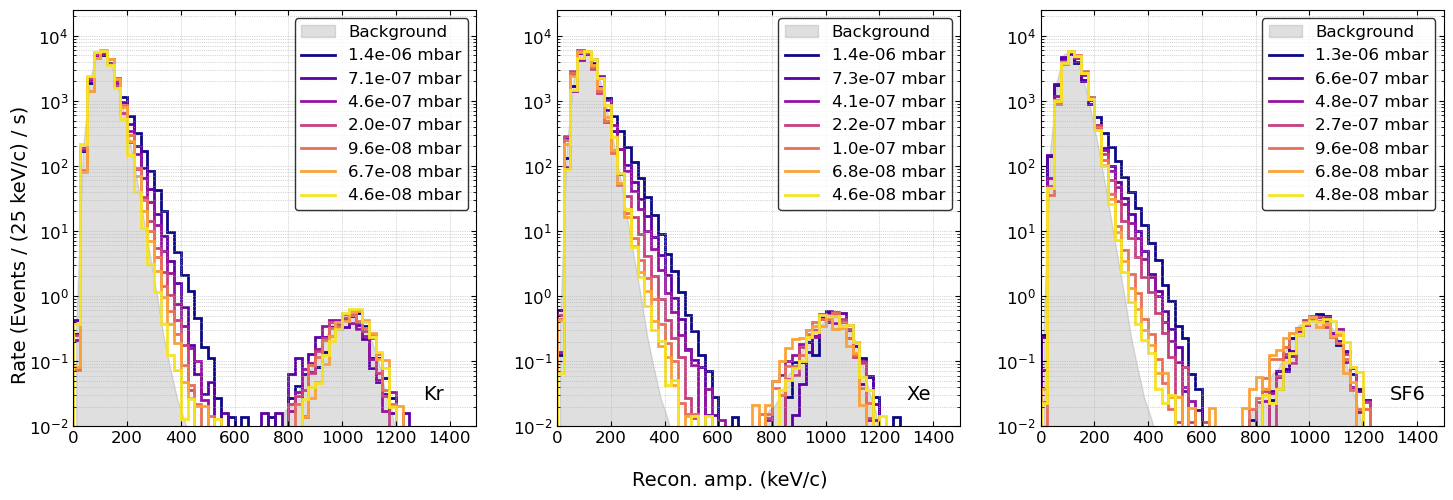

In [10]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], [ 'Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_wcal_avg/(50e-6*np.sum(hh_bg_wcal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, p_mbar) in zip(colors, hhs[gas]):
        norm = 50e-6 * np.sum(hh)
        ax.stairs(hh/norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.legend(edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()


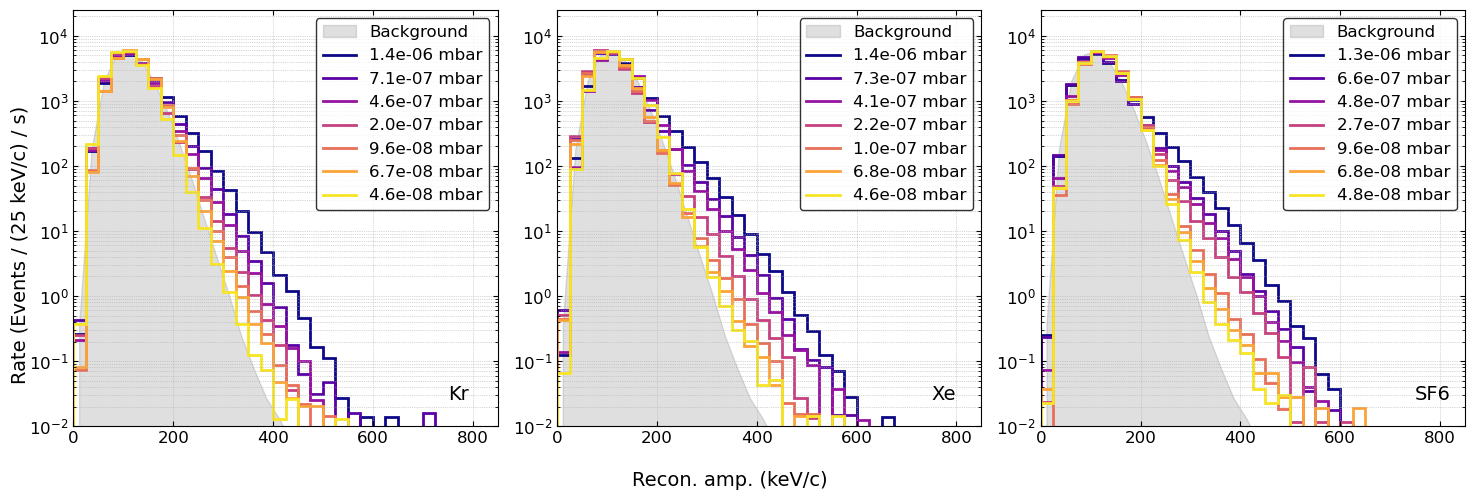

In [11]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_avg/(50e-6*np.sum(hh_bg_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, p_mbar) in zip(colors, hhs[gas]):
        norm = 50e-6 * np.sum(hh)
        ax.stairs(hh_nocal / norm, edges=bins, color=c, linewidth=2, linestyle='-', label=f'{p_mbar:.1e} mbar')

    ax.text(750, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 850)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.legend(edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()


In [12]:
import sys
sys.path.append('../../')
import recon_histograms as rh

# ── Data-selection cut breakdown ──────────────────────────────────────────
# Show what fraction of raw amplitude entries survive each sequential cut,
# for one representative dataset (highest-pressure xenon).

_dataset, _data_type, _prefix, _nfiles = rh.datasets_config['xenon'][-2]
recon = rh.read_recon_all(_dataset, _data_type, _prefix, _nfiles)
amps_all, good_det_all, noise_all, chi2_all, drive_all, fres_all = recon[:6]
idx_all, pulse_all = recon[7], recon[8]

n_searches = amps_all[0].shape[1]
drive_freq, ref_freq = rh.drive_freq, rh.ref_freq

total_windows = 0
total_amps    = 0

pass_good_det  = 0
pass_noise     = 0
pass_drive     = 0   # all three window cuts combined → "good_window"
pass_chi2      = 0
pass_dc        = 0
pass_cal       = 0

for i in range(len(amps_all)):
    nw = amps_all[i].shape[0]
    total_windows += nw
    total_amps    += nw * n_searches

    good_det = good_det_all[i]
    noise_ok = noise_all[i] * rh.amp2kev < rh.noise_threshold_kev
    norm_drive = (
        drive_all[i]
        * (fres_all[i]**2 - drive_freq**2)**2
        / (ref_freq**2 - drive_freq**2)**2
    )
    good_window = good_det & noise_ok & (norm_drive > rh.normalized_drive_power_threshold)

    pass_good_det += np.sum(good_det)          * n_searches
    pass_noise    += np.sum(good_det & noise_ok) * n_searches
    pass_drive    += np.sum(good_window)         * n_searches

    # Amplitude-level cuts (only within good windows)
    amps = np.array(amps_all[i], dtype=np.float64)
    amps[chi2_all[i] >= rh.chi2_threshold] = np.nan
    good_amps_chi2 = amps[good_window].ravel()
    pass_chi2 += np.sum(~np.isnan(good_amps_chi2))

    amps_dc = rh.throw_away_doublecounts(amps, good_window, idx_all[i])
    good_amps_dc = amps_dc[good_window].ravel()
    pass_dc += np.sum(~np.isnan(good_amps_dc))

    is_cal = rh.flag_cal_pulses(idx_all[i], pulse_all[i], amps_dc)
    amps_nocal = np.where(is_cal, np.nan, amps_dc)
    good_amps_nocal = amps_nocal[good_window].ravel()
    pass_cal += np.sum(~np.isnan(good_amps_nocal))

def pct(n): return 100 * n / total_amps

print(f'Dataset: {_dataset}  ({_nfiles} files)')
print(f'{"Cut step":<40} {"Amps retained":>14}  {"% of raw":>8}  {"% cut":>8}')
print('-' * 76)
print(f'{"Raw (all windows × n_searches)":<40} {total_amps:>14,}  {100:>7.1f}%  {"—":>8}')
print(f'{"After good_detection":<40} {pass_good_det:>14,}  {pct(pass_good_det):>7.1f}%  {100-pct(pass_good_det):>7.1f}%')
print(f'{"After noise < 70 keV/c":<40} {pass_noise:>14,}  {pct(pass_noise):>7.1f}%  {100-pct(pass_noise):>7.1f}%')
print(f'{"After norm_drive > threshold":<40} {pass_drive:>14,}  {pct(pass_drive):>7.1f}%  {100-pct(pass_drive):>7.1f}%')
print(f'{"  [within good windows] chi2 < 700":<40} {pass_chi2:>14,}  {pct(pass_chi2):>7.1f}%  {100-pct(pass_chi2):>7.1f}%')
print(f'{"  [within good windows] doublecount":<40} {pass_dc:>14,}  {pct(pass_dc):>7.1f}%  {100-pct(pass_dc):>7.1f}%')
print(f'{"  [nocal] cal-pulse removal":<40} {pass_cal:>14,}  {pct(pass_cal):>7.1f}%  {100-pct(pass_cal):>7.1f}%')

Dataset: 20260219_p6e_7e-8mbar  (25 files)
Cut step                                  Amps retained  % of raw     % cut
----------------------------------------------------------------------------
Raw (all windows × n_searches)                3,272,000    100.0%         —
After good_detection                          3,267,910     99.9%      0.1%
After noise < 70 keV/c                        3,096,130     94.6%      5.4%
After norm_drive > threshold                  2,993,880     91.5%      8.5%
  [within good windows] chi2 < 700            2,885,949     88.2%     11.8%
  [within good windows] doublecount           2,813,857     86.0%     14.0%
  [nocal] cal-pulse removal                   2,813,402     86.0%     14.0%
